# S&P 500 EGARCH and Structural-Break Development Analysis

## Purpose of This Notebook

This notebook documents the preliminary S&P 500 analysis used to develop and evaluate the volatility-regime identification methodology before applying the final procedure to the full set of 23 assets.

The S&P 500 is used here as a development case to:

1. Estimate daily conditional volatility using an **EGARCH(1,1,1)** model.
2. Apply the custom **Bai–Perron-style structural-break procedure** to the estimated conditional-volatility series.
3. Examine the sensitivity of the moving-block bootstrap to alternative **block lengths (5, 10, and 20 trading observations)**.
4. Determine the baseline structural-break specification subsequently used in the final multi-asset analysis.


In [ ]:
# Set up and data loading

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from arch import arch_model
from src.bai_perron import BaiPerron

# Load preprocessed S&P 500 returns
processed_path = "data/processed/processed_returns.csv"

df = pd.read_csv(
    processed_path,
    parse_dates=["Date"]
)

df = df.sort_values("Date").reset_index(drop=True)

print(f"Observations: {len(df):,}")
print(f"Sample period: {df['Date'].min().date()} to {df['Date'].max().date()}")

df.head()

Dataset shape: (6683, 7)


,Date,Open,High,Low,Close,Volume,LogReturn
0,2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,-3.909918
1,2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,0.192034
2,2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,0.095522
3,2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,2.672995
4,2000-01-10,1441.469971,1464.359985,1441.469971,1457.599976,1064800000,1.112782


In [ ]:
# Validate inputs before fitting EGARCH
required_columns = ["Date", "LogReturn"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Missing values:")
print(df[required_columns].isna().sum())

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'LogReturn'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6683 entries, 0 to 6682
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6683 non-null   datetime64[ns]
 1   Open       6683 non-null   float64       
 2   High       6683 non-null   float64       
 3   Low        6683 non-null   float64       
 4   Close      6683 non-null   float64       
 5   Volume     6683 non-null   int64         
 6   LogReturn  6683 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 365.6 KB
None
Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
LogReturn    0
dtype: int64


In [ ]:
# S&P 500 Return Series
# Extract log returns for EGARCH estimation
returns = df["LogReturn"].dropna().copy()

print(returns.describe())

0   -3.909918
1    0.192034
2    0.095522
3    2.672995
4    1.112782
Name: LogReturn, dtype: float64
count    6683.000000
mean        0.024516
std         1.214949
min       -12.765220
25%        -0.472909
50%         0.063733
75%         0.588149
max        10.957197
Name: LogReturn, dtype: float64


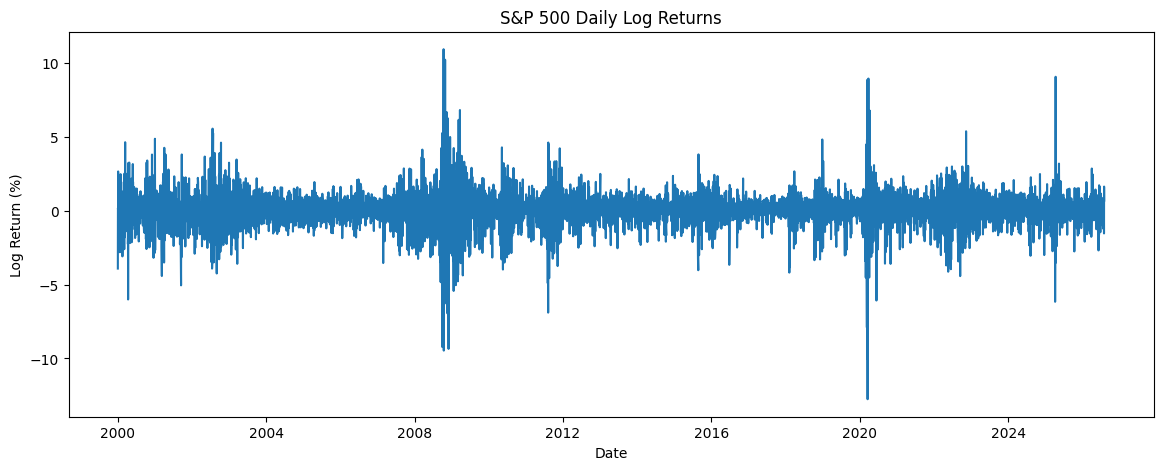

In [ ]:
# Plot the returns visually
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["LogReturn"])

plt.title("S&P 500 Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return (%)")

plt.tight_layout()
plt.show()

In [ ]:
# Estimate EGARCH(1,1,1)
egarch_model = arch_model(
    returns,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1
)

egarch_result = egarch_model.fit(disp="off")

print(egarch_result.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:              LogReturn   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -9044.14
Distribution:                  Normal   AIC:                           18098.3
Method:            Maximum Likelihood   BIC:                           18132.3
                                        No. Observations:                 6683
Date:                Fri, Sep 11 2026   Df Residuals:                     6682
Time:                        22:05:53   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0216  9.724e-03      2.226  2.601e-02 [2.

In [ ]:
# Extract estimated conditional volatility
# This is the input for the Bai-Perron analysis
df["ConditionalVolatility"] = (
    egarch_result.conditional_volatility
)

df[
    ["Date", "LogReturn", "ConditionalVolatility"]
].head()

,Date,LogReturn,ConditionalVolatility
0,2000-01-04,-3.909918,1.607433
1,2000-01-05,0.192034,2.140099
2,2000-01-06,0.095522,1.973320
3,2000-01-07,2.672995,1.823476
4,2000-01-10,1.112782,1.699099


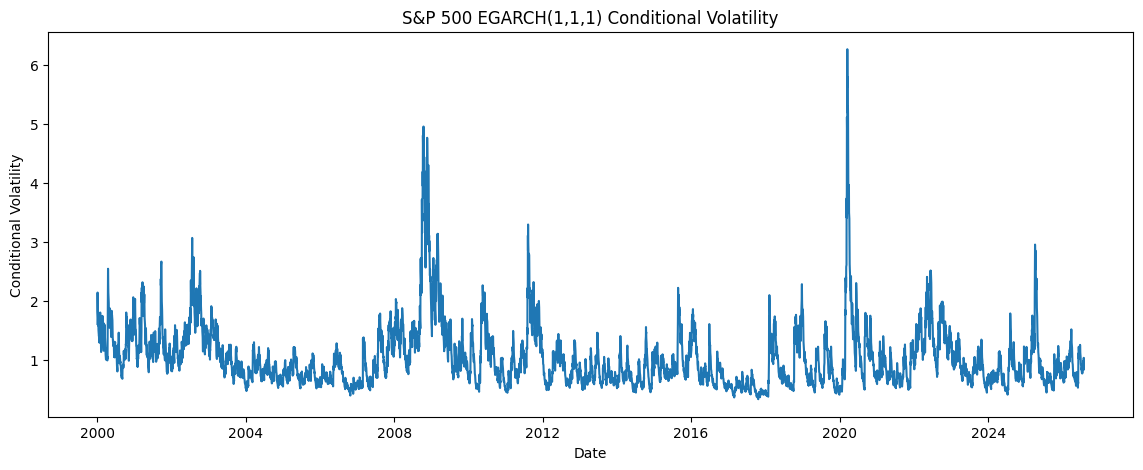

In [ ]:
# Plot EGARCH volatility

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["ConditionalVolatility"]
)

plt.title("S&P 500 EGARCH(1,1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility")

plt.tight_layout()
plt.show()

In [ ]:
# Prepare conditional volatility series for the analysis
volatility = (
    df["ConditionalVolatility"]
    .dropna()
    .to_numpy()
)

print(f"Volatility observations: {len(volatility):,}")
print(f"Minimum: {volatility.min():.4f}")
print(f"Maximum: {volatility.max():.4f}")

Number of volatility observations: 6683
Minimum volatility: 0.3328497974775981
Maximum volatility: 6.263793638472459


In [ ]:
# In the simulation, used observation numbers such as 200 or 400 but here we need actual dates

# Corresponding trading dates
volatility_dates = (
    df.loc[
        df["ConditionalVolatility"].notna(),
        "Date"
    ]
    .reset_index(drop=True)
)

assert len(volatility) == len(volatility_dates)

print(
    f"Structural-break sample: "
    f"{volatility_dates.iloc[0].date()} to "
    f"{volatility_dates.iloc[-1].date()}"
)

Number of volatility values: 6683
Number of dates: 6683


## Bootstrap Block-Length Sensitivity Analysis

The moving-block bootstrap requires the selection of a block length, which determines how many consecutive observations are resampled together.

During development, 3 block lengths were tested using the S&P 500 conditional-volatility series:

- **5 trading observations**
- **10 trading observations**
- **20 trading observations**

All other structural-break parameters are held constant.

In [ ]:
# Common structural-break parameters
min_segment = 60
max_breaks = 20
n_simulations = 500
alpha = 0.05

block_sizes = [5, 10, 20]

print("Structural-break sensitivity settings:")
print(f"Minimum segment length: {min_segment}")
print(f"Maximum breaks:         {max_breaks}")
print(f"Bootstrap simulations:  {n_simulations}")
print(f"Significance level:      {alpha}")
print(f"Block lengths tested:    {block_sizes}")

In [ ]:
# Run the selected baseline specification for the S&P 500

real_final_breaks = (
    bp_real_final
    .sequential_break_detection(
        volatility,
        n_simulations=500,
        alpha=0.05,
        block_size=10,
        random_state=42
    )
)

In [ ]:
# Compare bootstrap block lengths
block_results = {}

for block_size in block_sizes:
    print(f"\n{'=' * 50}")
    print(f"Block length: {block_size}")
    print(f"{'=' * 50}")

    model = BaiPerron(
        volatility,
        max_breaks=max_breaks,
        min_segment=min_segment
    )

    breakpoints = model.fit_sequential(
        n_simulations=n_simulations,
        alpha=alpha,
        block_size=block_size
    )

    block_results[block_size] = breakpoints

    print(f"Detected breaks: {len(breakpoints)}")

In [ ]:
# Run the final structural-break analysis

real_final_breaks = (
    bp_real_final
    .sequential_break_detection(
        volatility,
        n_simulations=500,
        alpha=0.05,
        block_size=10,
        random_state=42
    )
)

Iteration 1: candidate=822, supF=461.6009, critical=108.9144
Iteration 2: candidate=1898, supF=194.5191, critical=115.5193
Iteration 3: candidate=2365, supF=1068.3524, critical=105.6877
Iteration 4: candidate=2187, supF=437.2399, critical=83.1185
Iteration 5: candidate=2251, supF=320.8509, critical=72.8857
Iteration 6: candidate=617, supF=151.9645, critical=76.8369
Iteration 7: candidate=702, supF=242.1301, critical=72.1327
Iteration 8: candidate=5066, supF=141.7156, critical=113.3740
Iteration 9: candidate=5126, supF=950.2446, critical=94.1348
Iteration 10: candidate=3021, supF=375.4889, critical=95.4023
Iteration 11: candidate=2913, supF=381.3485, critical=78.3079
Iteration 12: candidate=5847, supF=221.1331, critical=92.0858
Iteration 13: candidate=5546, supF=350.8626, critical=76.7978
Iteration 14: candidate=5258, supF=169.1220, critical=69.2131
Iteration 15: candidate=908, supF=133.8347, critical=81.6568
Iteration 16: candidate=2689, supF=102.3052, critical=78.0999
Iteration 17: ca

In [ ]:
# Inspect the baseline structural-break results

print(f"Number of detected structural breaks: {len(real_final_breaks)}")
print(f"Breakpoint indices: {real_final_breaks}")

Number of final structural breaks: 20
Final breakpoint indices: [617, 702, 822, 908, 1663, 1796, 1898, 2187, 2251, 2365, 2598, 2689, 2801, 2913, 3021, 5066, 5126, 5258, 5546, 5847]


In [ ]:
# Validate detected breakpoints

assert real_final_breaks == sorted(real_final_breaks)
assert len(real_final_breaks) == len(set(real_final_breaks))
assert all(
    0 < bp < len(volatility)
    for bp in real_final_breaks
)

print("Breakpoint validation passed.")

Number of breakpoints: 20
Number of unique breakpoints: 20
Duplicate breakpoint indices: []
No duplicate breakpoint indices detected.


In [ ]:
# Convert breakpoint indices to calendar dates

breakpoint_dates = pd.DataFrame({
    "Breakpoint": range(1, len(real_final_breaks) + 1),
    "Index": real_final_breaks,
    "Date": [
        dates.iloc[bp]
        for bp in real_final_breaks
    ]
})

breakpoint_dates

Breakpoint validation passed:
- All breakpoint indices are unique.
- All breakpoint indices are chronologically ordered.


## Construction of Final Volatility Regimes

The detected structural breakpoints divide the S&P 500 conditional-volatility series into distinct volatility regimes. Each regime represents a contiguous period during which the mean level of estimated conditional volatility is treated as stable.

In [ ]:
# Construct regime boundaries

boundaries = [0] + real_final_breaks + [len(volatility)]

In [ ]:
# Construct volatility regimes

regimes = []

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]

    regime_volatility = volatility[start_idx:end_idx]

    regimes.append({
        "Regime": i + 1,
        "StartDate": volatility_dates.iloc[start_idx],
        "EndDate": volatility_dates.iloc[end_idx - 1],
        "Observations": end_idx - start_idx,
        "MeanVolatility": regime_volatility.mean()
    })

regime_df = pd.DataFrame(regimes)

regime_df

In [ ]:
# Calculate percentage changes in mean volatility between adjacent regimes

regime_df["VolatilityChangePct"] = (
    regime_df["MeanVolatility"]
    .pct_change()
    .mul(100)
)

regime_df